In [19]:
import os
import shutil

repo_path = "/content/Flight-Delay-Forecasting"

# clone ONLY if not already present in this session
if not os.path.exists(repo_path):
    !git clone https://{GITHUB_TOKEN}@github.com/kevinbrugnera/Flight-Delay-Forecasting.git {repo_path}
    %cd {repo_path}
    !git checkout develop
    !git config --global user.email "sarapasquato03@gmail.com"
    !git config --global user.name "sarapasquato"
else:
    %cd {repo_path}
    !git pull origin develop  # pull any teammate changes before overwriting

# copy the updated notebook from Drive into the repo
filename = os.path.basename(NOTEBOOK_DRIVE_PATH)
shutil.copy(NOTEBOOK_DRIVE_PATH, os.path.join(repo_path, filename))

# commit and push
!git add {filename}
!git commit -m "{COMMIT_MESSAGE}"
!git push origin develop

print(f"\n✅ Done: {filename} uploaded to GitHub (develop branch)")

/content/Flight-Delay-Forecasting
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 17.87 KiB | 415.00 KiB/s, done.
From https://github.com/kevinbrugnera/Flight-Delay-Forecasting
 * branch            develop    -> FETCH_HEAD
   f34fd04..5ad242a  develop    -> origin/develop
Updating f34fd04..5ad242a
Fast-forward
 .gitignore        |   3 +-
 Project.ipynb     | 884 +++++++++++++++++++++++++++++++++++++++++++++++-------
 data_loader.py    | 439 +++++++++++++++++++++++++++
 exploration.ipynb | 175 ++++++-----
 4 files changed, 1323 insertions(+), 178 deletions(-)
 create mode 100644 data_loader.py
[develop a27d242] Fixing the early stopping issue
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite tabular_pipeline_aeolus_lgbm.ipynb (95%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
De

In [1]:
## 0. Setup (CPU-only: LightGBM doesn't need GPU)

!pip install -q lightgbm optuna shap pyarrow psutil

import gc, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
import shap
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score, classification_report)
import pyarrow.parquet as pq
import psutil

optuna.logging.set_verbosity(optuna.logging.WARNING)

from google.colab import drive
drive.mount('/content/drive')

def checkpoint(label):
    rss = psutil.Process().memory_info().rss / 1024**2
    print(f"[{label}] RAM process: {rss:.0f} MB")

DATA_DIR = "/content/drive/MyDrive/aeolus_data/"
MODELS_DIR = DATA_DIR + "models/"
os.makedirs(MODELS_DIR, exist_ok=True)

n_threads = max(os.cpu_count() or 2, 1)
print(f"CPUs available: {n_threads}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.9 MB/s eta 0:00:00
Mounted at /content/drive
CPUs available: 2


In [2]:
## 1. Loading data

def sample_parquet_streaming(path, frac=0.3, seed=42, batch_size=200_000):
    rng = np.random.default_rng(seed)
    pf = pq.ParquetFile(path)
    chunks = []
    for batch in pf.iter_batches(batch_size=batch_size):
        chunk = batch.to_pandas()
        sampled = chunk.sample(frac=frac, random_state=rng.integers(0, 1_000_000))
        chunks.append(sampled)
    return pd.concat(chunks, ignore_index=True)


train = sample_parquet_streaming(DATA_DIR + "train_encoded.parquet", frac=1)
val = pd.read_parquet(DATA_DIR + "val_encoded.parquet")
test = pd.read_parquet(DATA_DIR + "test_encoded.parquet")

target_col = "ARR_DELAY_BIN"
cat_cols = ["OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH", "FL_DAY", "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX"]
exclude_cols = {"ARR_DELAY", "DEP_DELAY", "ARR_DELAY_BIN", "DEP_DELAY_BIN", "_FLIGHT_DATE", "dep_hour_bucket"}
feature_cols = [c for c in train.columns if c not in exclude_cols]
lgbm_cat_cols = [c for c in cat_cols if c != "OP_CARRIER_FL_NUM"]  # hight cardinality

print(f"train: {train.shape}, val: {val.shape}, test: {test.shape}")
checkpoint("after loading")

train: (11389014, 38), val: (3868288, 38), test: (3868288, 38)
[after loading] RAM process: 4734 MB


In [3]:
## 2. Training baseline LightGBM

y_train, y_val, y_test = train[target_col], val[target_col], test[target_col]
scale_pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

train_set = lgb.Dataset(train[feature_cols], label=y_train, categorical_feature=lgbm_cat_cols)
val_set = lgb.Dataset(val[feature_cols], label=y_val, categorical_feature=lgbm_cat_cols, reference=train_set)

params = {
    "objective": "binary", "metric": ["auc", "binary_logloss"],
    "scale_pos_weight": scale_pos_weight, "learning_rate": 0.05,
    "num_leaves": 63, "max_bin": 63, "num_threads": n_threads, "verbose": -1,
}
evals_result_baseline = {}

model = lgb.train(
    params, train_set, num_boost_round=500,
    valid_sets=[train_set, val_set], valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(30, first_metric_only=True),
        lgb.log_evaluation(50),
        lgb.record_evaluation(evals_result_baseline),  # <-- nuovo: salva la storia per il plot
    ],
)
print(f"best_iteration = {model.best_iteration}")
gc.collect()

model.save_model(MODELS_DIR + "lgbm_baseline.txt")
print("Model saved on Drive.")
checkpoint("after training")

scale_pos_weight = 3.95
Training until validation scores don't improve for 30 rounds
[50]	train's auc: 0.711605	train's binary_logloss: 0.599957	val's auc: 0.650188	val's binary_logloss: 0.616697
[100]	train's auc: 0.724906	train's binary_logloss: 0.610929	val's auc: 0.654933	val's binary_logloss: 0.636208
[150]	train's auc: 0.732418	train's binary_logloss: 0.606261	val's auc: 0.657621	val's binary_logloss: 0.635299
[200]	train's auc: 0.737256	train's binary_logloss: 0.602192	val's auc: 0.658752	val's binary_logloss: 0.632872
[250]	train's auc: 0.741004	train's binary_logloss: 0.599085	val's auc: 0.659447	val's binary_logloss: 0.630949
[300]	train's auc: 0.743667	train's binary_logloss: 0.596879	val's auc: 0.659971	val's binary_logloss: 0.62946
[350]	train's auc: 0.745925	train's binary_logloss: 0.59498	val's auc: 0.660297	val's binary_logloss: 0.62811
[400]	train's auc: 0.748073	train's binary_logloss: 0.593188	val's auc: 0.660847	val's binary_logloss: 0.626642
[450]	train's auc: 0.74

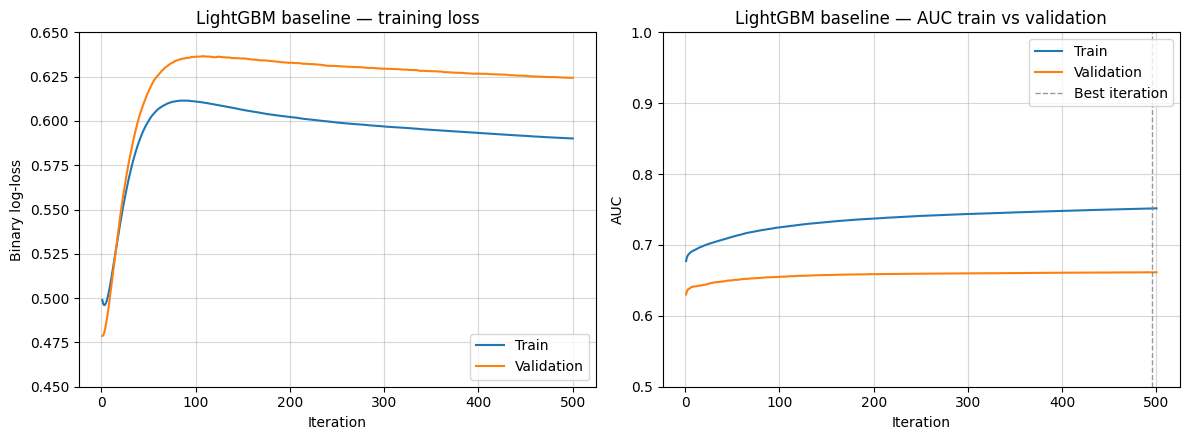

In [17]:
## Learning curve — LightGBM baseline

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rounds = range(1, len(evals_result_baseline["train"]["auc"]) + 1)

axes[0].plot(rounds, evals_result_baseline["train"]["binary_logloss"], label="Train")
axes[0].plot(rounds, evals_result_baseline["val"]["binary_logloss"], label="Validation")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Binary log-loss")
axes[0].set_title("LightGBM baseline — training loss")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.5)
axes[0].set_ylim(0.45,0.65)


axes[1].plot(rounds, evals_result_baseline["train"]["auc"],  label="Train")
axes[1].plot(rounds, evals_result_baseline["val"]["auc"], label="Validation")
axes[1].axvline(model.best_iteration, color="gray", linestyle="--", linewidth=1, alpha=0.8,label="Best iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("AUC")
axes[1].set_title("LightGBM baseline — AUC train vs validation")
axes[1].legend(loc="upper right")
axes[1].set_ylim(0.5,1)
axes[1].grid(alpha=0.5)

plt.tight_layout()
#plt.savefig(data_dir + "lgbm_baseline_learning_curve.pdf")
plt.show()

In [5]:
## 3. Optimal threshold + metrics on train/val/test

y_prob_train = model.predict(train[feature_cols], num_iteration=model.best_iteration)
y_prob_val = model.predict(val[feature_cols], num_iteration=model.best_iteration)
y_prob_test = model.predict(test[feature_cols], num_iteration=model.best_iteration)

def find_best_threshold(y_true, y_prob, n_thresholds=50):
    thresholds = np.linspace(y_prob.min(), y_prob.max(), n_thresholds)
    f1s = [f1_score(y_true, (y_prob > t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    print(f"Optimal thershold: {best_t:.4f} (probability range: [{y_prob.min():.4f}, {y_prob.max():.4f}])")
    return best_t


def metrics_from_probs(y_true, y_prob, threshold):
    y_pred = (y_prob > threshold).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_prob), "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred), "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
    }


threshold = find_best_threshold(y_val, y_prob_val)
results = {
    "train": metrics_from_probs(y_train, y_prob_train, threshold),
    "val": metrics_from_probs(y_val, y_prob_val, threshold),
    "test": metrics_from_probs(y_test, y_prob_test, threshold),
}
report = pd.DataFrame(results).T
report.insert(0, "threshold", threshold)
print(report.round(4).to_string())

metrics = results["test"]
gap_auc = results["train"]["auc"] - results["test"]["auc"]
print(f"\nGap AUC train-test: {gap_auc:.4f} {'⚠️ possible overfitting' if gap_auc > 0.05 else '✅ ok'}")

report.to_csv(MODELS_DIR + "lgbm_baseline_metrics.csv")
checkpoint("after evaluation")

Optimal thershold: 0.4667 (probability range: [0.0355, 0.9541])
       threshold     auc  accuracy      f1  precision  recall
train     0.4667  0.7515    0.6563  0.4606     0.3371  0.7269
val       0.4667  0.6615    0.6162  0.3725     0.2670  0.6161
test      0.4667  0.6852    0.6127  0.4014     0.2875  0.6644

Gap AUC train-test: 0.0663 ⚠️ possible overfitting
[after evaluation] RAM process: 5535 MB


In [5]:
## 4. Feature importance

importance = pd.Series(model.feature_importance(importance_type="gain"), index=feature_cols).sort_values(ascending=False)
print(importance.head(15))
importance.to_csv(MODELS_DIR + "lgbm_feature_importance.csv")

FL_WEEK             7.121224e+06
ORIGIN_INDEX        4.778230e+06
OP_CARRIER          4.234519e+06
CRS_DEP_TIME_MIN    3.688039e+06
DEST_INDEX          3.535301e+06
dep_hour_sin        2.944610e+06
FL_DAY              2.850828e+06
arr_hour_cos        1.324203e+06
O_PRCP              1.220508e+06
D_PRCP              9.435829e+05
O_TEMP              9.204282e+05
dow_sin             7.238555e+05
CRS_ARR_TIME_MIN    4.611124e+05
arr_hour_sin        3.894837e+05
FL_YEAR             3.136138e+05
dtype: float64


In [6]:
## 5. Evaluation for subgroup (month, airport)

def subgroup_report(group_col, top_n=None, min_support=30):
    tmp = test[[group_col, target_col]].copy()
    tmp["y_prob"] = y_prob_test
    tmp["y_pred"] = (y_prob_test > threshold).astype(int)
    rows = []
    for group_val, sub in tmp.groupby(group_col):
        if len(sub) < min_support or sub[target_col].nunique() < 2:
            continue
        rows.append({"group": group_val, "n": len(sub),
                      "auc": roc_auc_score(sub[target_col], sub["y_prob"]),
                      "f1": f1_score(sub[target_col], sub["y_pred"])})
    result = pd.DataFrame(rows).sort_values("n", ascending=False)
    return result.head(top_n).reset_index(drop=True) if top_n else result.reset_index(drop=True)

print(">>> For month")
print(subgroup_report("FL_MONTH"))
print("\n>>> Top 10 airports")
print(subgroup_report("ORIGIN_INDEX", top_n=10))

>>> For month
   group       n       auc        f1
0      9  603859  0.695140  0.511891
1      1  600153  0.639536  0.263713
2     10  596087  0.697289  0.452328
3      3  574089  0.632291  0.372034
4     11  571187  0.662921  0.326192
5      2  563258  0.630175  0.285609
6      8  359655  0.688665  0.455761

>>> Top 10 airports
   group       n       auc        f1
0     20  189118  0.701389  0.414257
1     84  175622  0.688366  0.453871
2     83  171151  0.671318  0.391800
3    224  156495  0.671326  0.429638
4     64  120358  0.694803  0.474812
5    173  108074  0.652253  0.341907
6    235  105006  0.672354  0.369418
7    171  104242  0.681159  0.395440
8    273   93758  0.621303  0.378626
9    179   87949  0.703302  0.398638


In [7]:
## 6. SHAP

sample = test[feature_cols].sample(n=min(2000, len(test)), random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print(mean_abs_shap.head(10))
del explainer, shap_values
gc.collect()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


FL_WEEK             0.261462
OP_CARRIER          0.201691
dep_hour_sin        0.148743
CRS_DEP_TIME_MIN    0.139105
ORIGIN_INDEX        0.133578
DEST_INDEX          0.119139
arr_hour_cos        0.103503
dow_sin             0.082737
great_circle_km     0.077572
FL_DAY              0.070116
dtype: float64


12

In [6]:
## 7. Hyperparameter tuning with Optuna

del train_set, val_set
gc.collect()
checkpoint("after freeing the main training datasets")

train_set_opt = lgb.Dataset(train[feature_cols], label=y_train, categorical_feature=lgbm_cat_cols,
                             params={"feature_pre_filter": False})
val_set_opt = lgb.Dataset(val[feature_cols], label=y_val, categorical_feature=lgbm_cat_cols,
                           reference=train_set_opt, params={"feature_pre_filter": False})


def objective(trial):
    p = {
        "objective": "binary", "metric": "auc", "scale_pos_weight": scale_pos_weight,
        "verbose": -1, "feature_pre_filter": False, "num_threads": n_threads, "max_bin": 63,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
    }
    m = lgb.train(p, train_set_opt, num_boost_round=150, valid_sets=[val_set_opt],
                   callbacks=[lgb.early_stopping(15, first_metric_only=True), lgb.log_evaluation(50)])
    score = roc_auc_score(y_val, m.predict(val[feature_cols], num_iteration=m.best_iteration))
    del m
    gc.collect()
    return score

[after freeing the main training datasets] RAM process: 5448 MB


In [ ]:
## 7a. Fast TEST with 3 trials

t0 = time.time()
study_test = optuna.create_study(direction="maximize")
study_test.optimize(objective, n_trials=3)
elapsed = time.time() - t0
print(f"3 trials: {elapsed:.1f}s -> estimate for 20 trials: {elapsed/3*20/60:.1f} minutes")
checkpoint("after test Optuna")

In [7]:
## 7b. Real tuning

import joblib

study = optuna.create_study(direction="maximize")

def save_callback(study, trial):
    joblib.dump(study, MODELS_DIR + "optuna_study_lgbm.pkl")

study.optimize(objective, n_trials=20, callbacks=[save_callback], show_progress_bar=True)
print("Best AUC:", study.best_value, "Params:", study.best_params)
checkpoint("after full tuning")

  0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.643066
[100]	valid_0's auc: 0.646409
[150]	valid_0's auc: 0.648764
Did not meet early stopping. Best iteration is:
[149]	valid_0's auc: 0.648809
Evaluated only: auc
Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.641254
[100]	valid_0's auc: 0.64445
[150]	valid_0's auc: 0.64725
Did not meet early stopping. Best iteration is:
[149]	valid_0's auc: 0.647272
Evaluated only: auc
Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.655792
[100]	valid_0's auc: 0.658109
Early stopping, best iteration is:
[125]	valid_0's auc: 0.658458
Evaluated only: auc
Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.649183
[100]	valid_0's auc: 0.654079
[150]	valid_0's auc: 0.656827
Did not meet early stopping. Best iteration is:
[148]	valid_0's auc: 0.656846
Evaluated only: auc
Training until validation scores don't improve for 15

In [8]:
## 8. Final retraining with best hyperparameters + evaluation

best_params = {
    "objective": "binary", "metric": ["auc", "binary_logloss"], "scale_pos_weight": scale_pos_weight,
    "verbose": -1, "feature_pre_filter": False, "num_threads": n_threads, "max_bin": 63,
    **study.best_params,
}
evals_result_tuned = {}

model_tuned = lgb.train(
    best_params, train_set_opt, num_boost_round=500,
    valid_sets=[train_set_opt, val_set_opt], valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(30, first_metric_only=True),
        lgb.log_evaluation(50),
        lgb.record_evaluation(evals_result_tuned),
    ],
)
model_tuned.save_model(MODELS_DIR + "lgbm_tuned.txt")

y_prob_train_t = model_tuned.predict(train[feature_cols], num_iteration=model_tuned.best_iteration)
y_prob_val_t = model_tuned.predict(val[feature_cols], num_iteration=model_tuned.best_iteration)
y_prob_test_t = model_tuned.predict(test[feature_cols], num_iteration=model_tuned.best_iteration)

threshold_tuned = find_best_threshold(y_val, y_prob_val_t)
results_tuned = {
    "train": metrics_from_probs(y_train, y_prob_train_t, threshold_tuned),
    "val": metrics_from_probs(y_val, y_prob_val_t, threshold_tuned),
    "test": metrics_from_probs(y_test, y_prob_test_t, threshold_tuned),
}
report_tuned = pd.DataFrame(results_tuned).T
print(report_tuned.round(4).to_string())

metrics_tuned = results_tuned["test"]
report_tuned.to_csv(MODELS_DIR + "lgbm_tuned_metrics.csv")
print(f"\nComparison AUC test — baseline: {metrics['auc']:.4f} | tuned: {metrics_tuned['auc']:.4f}")
checkpoint("final")

Training until validation scores don't improve for 30 rounds
[50]	train's auc: 0.728781	train's binary_logloss: 0.607736	val's auc: 0.655504	val's binary_logloss: 0.634621
[100]	train's auc: 0.743014	train's binary_logloss: 0.597489	val's auc: 0.659214	val's binary_logloss: 0.631079
[150]	train's auc: 0.750149	train's binary_logloss: 0.591412	val's auc: 0.660546	val's binary_logloss: 0.627379
[200]	train's auc: 0.755179	train's binary_logloss: 0.587087	val's auc: 0.660839	val's binary_logloss: 0.624339
[250]	train's auc: 0.759314	train's binary_logloss: 0.583491	val's auc: 0.661224	val's binary_logloss: 0.622277
Early stopping, best iteration is:
[233]	train's auc: 0.758056	train's binary_logloss: 0.584594	val's auc: 0.661282	val's binary_logloss: 0.622684
Evaluated only: auc
Optimal thershold: 0.4621 (probability range: [0.0307, 0.9498])
          auc  accuracy      f1  precision  recall
train  0.7581    0.6575  0.4650     0.3395  0.7373
val    0.6613    0.6142  0.3729     0.2666  0.6

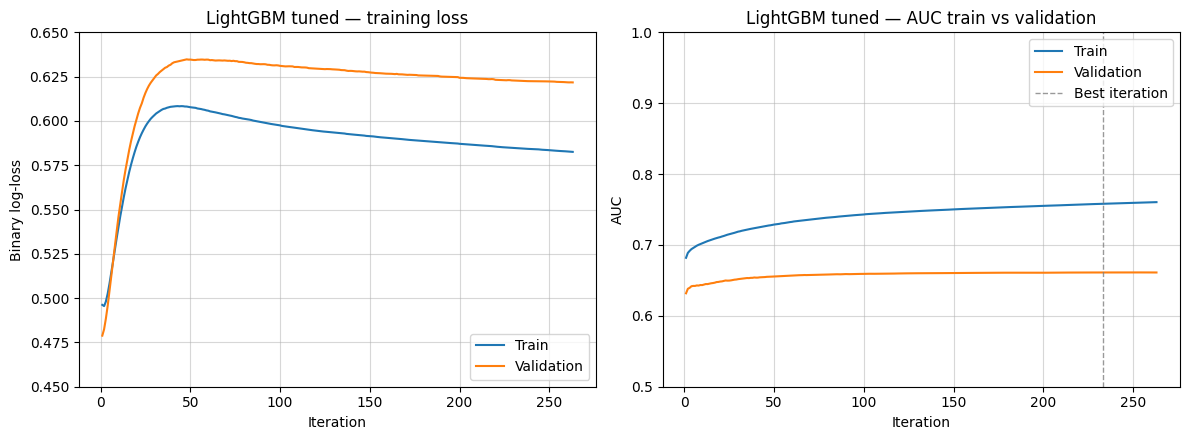

In [16]:
## Learning curve — LightGBM tuned (loss + AUC)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rounds_tuned = range(1, len(evals_result_tuned["train"]["auc"]) + 1)

axes[0].plot(rounds_tuned, evals_result_tuned["train"]["binary_logloss"], label="Train")
axes[0].plot(rounds_tuned, evals_result_tuned["val"]["binary_logloss"], label="Validation")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Binary log-loss")
axes[0].set_title("LightGBM tuned — training loss")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.5)
axes[0].set_ylim(0.45,0.65)


axes[1].plot(rounds_tuned, evals_result_tuned["train"]["auc"],  label="Train")
axes[1].plot(rounds_tuned, evals_result_tuned["val"]["auc"], label="Validation")
axes[1].axvline(model_tuned.best_iteration, color="gray", linestyle="--", linewidth=1, alpha=0.8, label="Best iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("AUC")
axes[1].set_title("LightGBM tuned — AUC train vs validation")
axes[1].legend(loc="upper right")
axes[1].set_ylim(0.5,1)
axes[1].grid(alpha=0.5)

plt.tight_layout()
#plt.savefig(data_dir + "lgbm_tuned_learning_curve.pdf")
plt.show()

In [ ]:
## Learning curve — LightGBM tuned, comparison with baseline

plt.figure(figsize=(7, 4.5))
plt.plot(evals_result_baseline["val"]["auc"], label="Baseline — val AUC", alpha=0.7)
plt.plot(evals_result_tuned["val"]["auc"], label="Tuned — val AUC", alpha=0.7)
plt.xlabel("Boosting round")
plt.ylabel("Validation AUC")
plt.title("LightGBM: baseline vs tuned — comparison learning curve")
plt.legend()
plt.tight_layout()
plt.savefig(data_dir + "lgbm_baseline_vs_tuned_learning_curve.png", dpi=150)
plt.ylim(0.5,1)
plt.grid(alpha=0.5)
plt.show()

In [15]:
## Subgroup evaluation — LightGBM tuned

def subgroup_report_tuned(group_col, top_n=None, min_support=30):
    tmp = test[[group_col, target_col]].copy()
    tmp["y_prob"] = y_prob_test_t
    tmp["y_pred"] = (y_prob_test_t > threshold_tuned).astype(int)
    rows = []
    for group_val, sub in tmp.groupby(group_col):
        if len(sub) < min_support or sub[target_col].nunique() < 2:
            continue
        rows.append({"group": group_val, "n": len(sub),
                      "auc": roc_auc_score(sub[target_col], sub["y_prob"]),
                      "f1": f1_score(sub[target_col], sub["y_pred"])})
    result = pd.DataFrame(rows).sort_values("n", ascending=False)
    return result.head(top_n).reset_index(drop=True) if top_n else result.reset_index(drop=True)


print(">>> LightGBM tuned — for month")
print(subgroup_report_tuned("FL_MONTH"))
print("\n>>> LightGBM tuned — top 10 airports")
print(subgroup_report_tuned("ORIGIN_INDEX", top_n=10))

>>> LightGBM tuned — for month
   group       n       auc        f1
0      9  603859  0.696747  0.512401
1      1  600153  0.641716  0.267113
2     10  596087  0.695319  0.451304
3      3  574089  0.626462  0.369694
4     11  571187  0.665169  0.328514
5      2  563258  0.633323  0.288159
6      8  359655  0.687452  0.454780

>>> LightGBM tuned — top 10 airports
   group       n       auc        f1
0     20  189118  0.701522  0.414838
1     84  175622  0.687364  0.451702
2     83  171151  0.673373  0.392753
3    224  156495  0.669414  0.428971
4     64  120358  0.693606  0.475543
5    173  108074  0.651714  0.340998
6    235  105006  0.669654  0.368483
7    171  104242  0.682411  0.396801
8    273   93758  0.623193  0.379151
9    179   87949  0.700389  0.398334


In [16]:
## SHAP — LightGBM tuned

sample_tuned = test[feature_cols].sample(n=min(2000, len(test)), random_state=42)
explainer_tuned = shap.TreeExplainer(model_tuned)
shap_values_tuned = explainer_tuned.shap_values(sample_tuned)

mean_abs_shap_tuned = pd.Series(np.abs(shap_values_tuned).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print("Top 10 feature (LightGBM tuned) for mean |SHAP|:")
print(mean_abs_shap_tuned.head(10))

del explainer_tuned, shap_values_tuned
gc.collect()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Top 10 feature (LightGBM tuned) for mean |SHAP|:
FL_WEEK             0.266445
OP_CARRIER          0.205531
dep_hour_sin        0.165643
ORIGIN_INDEX        0.144509
CRS_DEP_TIME_MIN    0.134046
DEST_INDEX          0.128054
arr_hour_cos        0.101616
great_circle_km     0.096072
CRS_ELAPSED_TIME    0.083886
dow_sin             0.079432
dtype: float64


12

In [17]:
## Feature importance — LightGBM tuned

importance_tuned = pd.Series(
    model_tuned.feature_importance(importance_type="gain"), index=feature_cols
).sort_values(ascending=False)

print("Top 15 feature (LightGBM tuned):")
print(importance_tuned.head(15))

importance_tuned.to_csv(MODELS_DIR + "lgbm_tuned_feature_importance.csv")

# direct comparison baseline vs tuned
comparison_importance = pd.DataFrame({
    "baseline": importance, "tuned": importance_tuned
}).sort_values("tuned", ascending=False)
print("\nComparison baseline vs tuned (top 10):")
print(comparison_importance.head(10))

Top 15 feature (LightGBM tuned):
FL_WEEK             5.226765e+06
ORIGIN_INDEX        4.141257e+06
DEST_INDEX          3.171049e+06
OP_CARRIER          2.918927e+06
dep_hour_sin        2.486280e+06
FL_DAY              2.352673e+06
CRS_DEP_TIME_MIN    2.240762e+06
O_PRCP              8.215085e+05
arr_hour_cos        8.112531e+05
O_TEMP              6.490187e+05
D_PRCP              6.352785e+05
dow_sin             5.292269e+05
arr_hour_sin        2.807513e+05
FL_YEAR             2.542448e+05
CRS_ARR_TIME_MIN    2.362077e+05
dtype: float64

Comparison baseline vs tuned (top 10):
                      baseline         tuned
FL_WEEK           7.121224e+06  5.226765e+06
ORIGIN_INDEX      4.778230e+06  4.141257e+06
DEST_INDEX        3.535301e+06  3.171049e+06
OP_CARRIER        4.234519e+06  2.918927e+06
dep_hour_sin      2.944610e+06  2.486280e+06
FL_DAY            2.850828e+06  2.352673e+06
CRS_DEP_TIME_MIN  3.688039e+06  2.240762e+06
O_PRCP            1.220508e+06  8.215085e+05
arr_hour_cos

In [ ]:
# Learning curve lgbm tuned
model_tuned, evals_tuned = train_lgbm_with_history(X_train, y_train, X_val, y_val, best_params)

plot_lgbm_learning_curve(
    evals_tuned, metric="auc",
    title="LightGBM Tuned - Learning Curve",
    best_iteration=model_tuned.best_iteration,
    save_path="lgbm_tuned_lc.png"
)